In [1]:
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv('../data/extraccion_cerveza_refrigerantes.csv', sep=';')
raw.columns = raw.columns.str.lower()
raw['fecha_comercial'] = pd.to_datetime(raw['fecha_comercial'])

predictions = pd.read_csv('../results/test_predictions.csv')
predictions['date'] = pd.to_datetime(predictions['date'])

In [2]:
# === PARAMETERS ===
PRODUCT = 7896045506934
STORE = 1
REPLENISHMENT_DAYS = 14

## 1. Current State: How stock actually behaves

In [3]:
store_data = raw[
    (raw['codigo_barras_sku'] == PRODUCT) & (raw['pdv_anonimizado'] == STORE)
].sort_values('fecha_comercial').copy()

store_data = store_data[store_data['stock'].notna()]

# Detect replenishments: stock goes up from one day to the next
store_data['stock_prev'] = store_data['stock'].shift(1)
store_data['replenishment'] = (store_data['stock'] - store_data['stock_prev'] + store_data['cant_vta']).clip(lower=0)
store_data.loc[store_data['replenishment'] < 10, 'replenishment'] = 0  # ignore noise

print(f'Product: {PRODUCT} | Store: {STORE}')
print(f'Period: {store_data["fecha_comercial"].min().date()} to {store_data["fecha_comercial"].max().date()}')
print(f'Total replenishments detected: {(store_data["replenishment"] > 0).sum()}')
print(f'Avg replenishment qty: {store_data[store_data["replenishment"] > 0]["replenishment"].mean():.0f}')
print(f'Days with stockout (stock <= 0): {(store_data["stock"] <= 0).sum()}')

Product: 7896045506934 | Store: 1
Period: 2024-10-03 to 2024-12-09
Total replenishments detected: 33
Avg replenishment qty: 742
Days with stockout (stock <= 0): 2


In [16]:
store_data.sort_values('fecha_comercial', inplace=True, ascending=False)
store_data

,pdv_anonimizado,fecha_comercial,codigo_barras_sku,nome_sku,qtd_conteudo_sku,imp_vta,cant_vta,vol_vta,stock,stock_prev,replenishment
2357187,1,2024-12-09,7896045506934,CERVEJA AMSTEL LAGER LATA 350ML,350.0,151.60,40.0,14000.0,3140.0,3180.0,0.0
3053242,1,2024-12-08,7896045506934,CERVEJA AMSTEL LAGER LATA 350ML,350.0,716.31,189.0,66150.0,3180.0,3696.0,0.0
947179,1,2024-12-07,7896045506934,CERVEJA AMSTEL LAGER LATA 350ML,350.0,1053.62,278.0,97300.0,3696.0,3810.0,164.0
1312816,1,2024-12-06,7896045506934,CERVEJA AMSTEL LAGER LATA 350ML,350.0,386.58,102.0,35700.0,3810.0,3919.0,0.0
1861808,1,2024-12-05,7896045506934,CERVEJA AMSTEL LAGER LATA 350ML,350.0,306.99,81.0,28350.0,3919.0,3919.0,81.0
...,...,...,...,...,...,...,...,...,...,...,...
2430592,1,2024-10-07,7896045506934,CERVEJA AMSTEL LAGER LATA 350ML,350.0,75.80,20.0,7000.0,3140.0,3161.0,0.0
3797851,1,2024-10-06,7896045506934,CERVEJA AMSTEL LAGER LATA 350ML,350.0,560.92,148.0,51800.0,3161.0,3454.0,0.0
1700466,1,2024-10-05,7896045506934,CERVEJA AMSTEL LAGER LATA 350ML,350.0,549.55,145.0,50750.0,3454.0,3868.0,0.0
2611592,1,2024-10-04,7896045506934,CERVEJA AMSTEL LAGER LATA 350ML,350.0,1130.22,378.0,132300.0,3868.0,3928.0,318.0


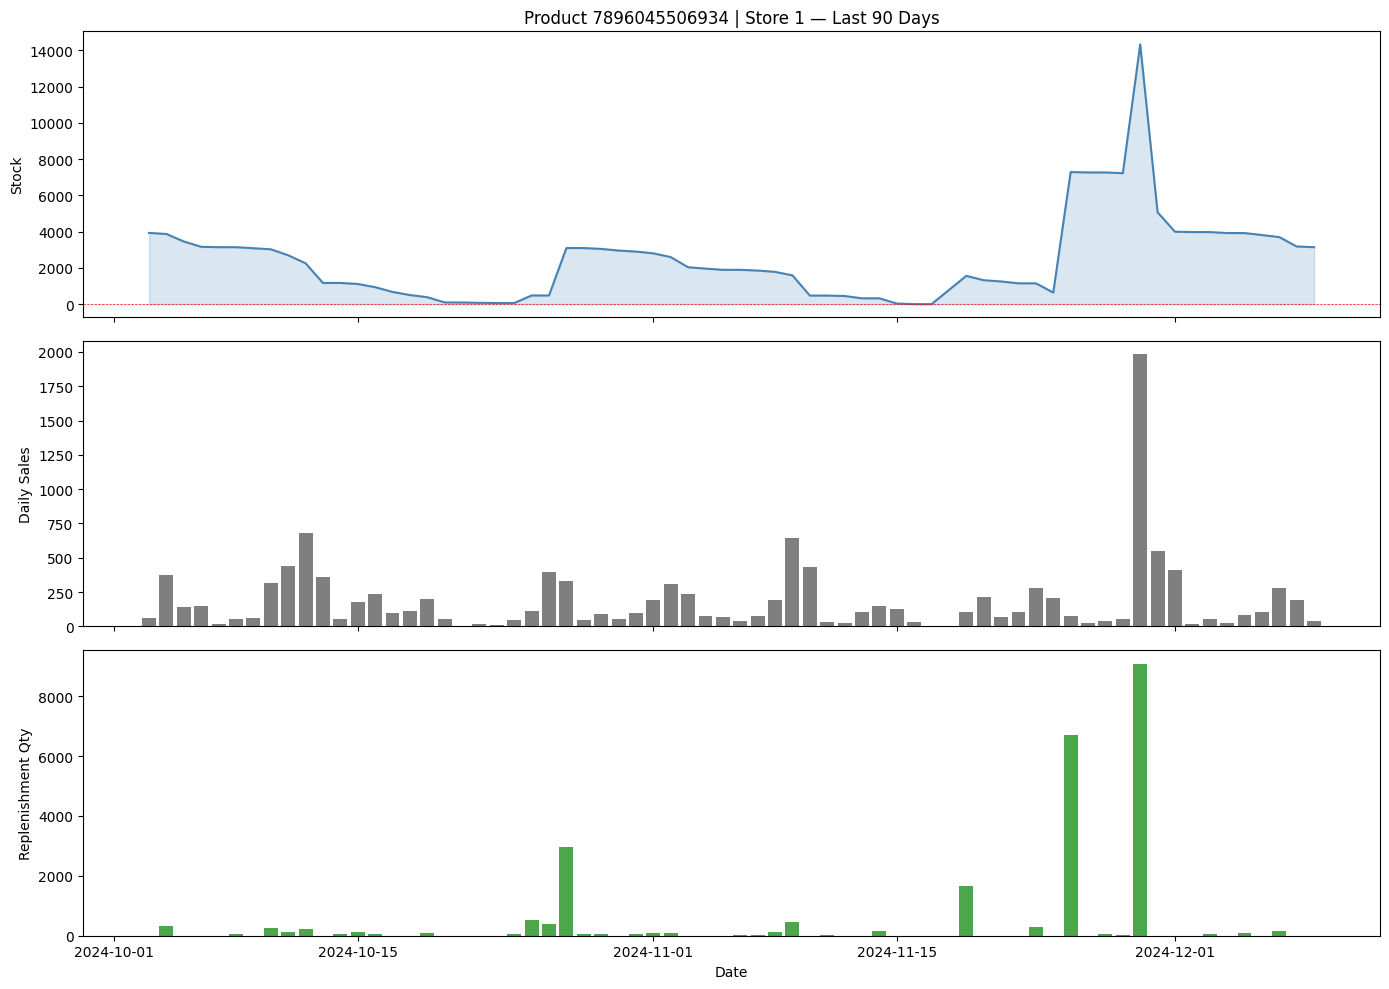

In [12]:
last_90 = store_data[store_data['fecha_comercial'] >= store_data['fecha_comercial'].max() - pd.Timedelta(days=90)]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Stock
ax1.plot(last_90['fecha_comercial'], last_90['stock'], color='steelblue', linewidth=1.5)
ax1.fill_between(last_90['fecha_comercial'], last_90['stock'], alpha=0.2, color='steelblue')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=0.5)
ax1.set_ylabel('Stock')
ax1.set_title(f'Product {PRODUCT} | Store {STORE} — Last 90 Days')

# Demand
ax2.bar(last_90['fecha_comercial'], last_90['cant_vta'], color='black', alpha=0.5)
ax2.set_ylabel('Daily Sales')

# Replenishments
repls = last_90[last_90['replenishment'] > 0]
ax3.bar(repls['fecha_comercial'], repls['replenishment'], color='green', alpha=0.7)
ax3.set_ylabel('Replenishment Qty')
ax3.set_xlabel('Date')

plt.tight_layout()
plt.show()


## 2. Replenishment Analysis: How much excess stock are they carrying?

In [5]:
# For the prediction period: what actually happened vs what was needed
pred_period = store_data[
    (store_data['fecha_comercial'] >= predictions['date'].min())
    & (store_data['fecha_comercial'] <= predictions['date'].min() + pd.Timedelta(days=REPLENISHMENT_DAYS - 1))
].copy()

if len(pred_period) > 0:
    actual_demand = pred_period['cant_vta'].sum()
    actual_replenishments = pred_period['replenishment'].sum()
    initial_stock = pred_period['stock'].iloc[0] + pred_period['cant_vta'].iloc[0]  # stock before first sale
    final_stock = pred_period['stock'].iloc[-1]
    avg_stock = pred_period['stock'].mean()

    print(f'=== What actually happened ({REPLENISHMENT_DAYS} days) ===')
    print(f'  Initial stock:       {initial_stock:.0f}')
    print(f'  Total demand:        {actual_demand:.0f}')
    print(f'  Replenishments:      {actual_replenishments:.0f}')
    print(f'  Final stock:         {final_stock:.0f}')
    print(f'  Avg stock held:      {avg_stock:.0f}')
    print(f'  Excess stock (avg):  {avg_stock - actual_demand / len(pred_period):.0f} units/day over demand')
else:
    print('No stock data in prediction period')

=== What actually happened (14 days) ===
  Initial stock:       507
  Total demand:        1449
  Replenishments:      2130
  Final stock:         639
  Avg stock held:      666
  Excess stock (avg):  554 units/day over demand


## 3. ML Simulation: Replenish based on predictions

In [6]:
def simulate(raw, predictions, product, store, replenishment_days):
    """Simulate: what if we replenished only what ML predicted?"""
    preds = (
        predictions[predictions['store_id'] == store]
        .sort_values('date')
        .head(replenishment_days)
        .reset_index(drop=True)
    )
    if len(preds) == 0:
        return None, None

    # Real stock data for the same period
    real = raw[
        (raw['codigo_barras_sku'] == product)
        & (raw['pdv_anonimizado'] == store)
        & (raw['stock'].notna())
        & (raw['fecha_comercial'] >= preds['date'].iloc[0])
        & (raw['fecha_comercial'] <= preds['date'].iloc[-1])
    ].sort_values('fecha_comercial')

    # Initial stock: stock at start of period (before sales)
    if len(real) > 0:
        initial_stock = real['stock'].iloc[0] + real['cant_vta'].iloc[0]
    else:
        initial_stock = 0

    predicted_demand = preds['prediction'].sum()
    actual_demand = preds['actual'].sum()

    sim = preds[['date', 'prediction', 'actual']].copy()

    # ML scenario: start from 0, replenish exactly what ML predicts
    sim['stock_ml'] = predicted_demand - sim['actual'].cumsum()

    # Real scenario: use actual stock values
    if len(real) > 0:
        sim = sim.merge(real[['fecha_comercial', 'stock']].rename(columns={'fecha_comercial': 'date', 'stock': 'stock_real'}), on='date', how='left')
    else:
        sim['stock_real'] = None

    summary = {
        'product': product,
        'store': store,
        'days': replenishment_days,
        'initial_stock_real': initial_stock,
        'predicted_demand': round(predicted_demand),
        'actual_demand': round(actual_demand),
        'prediction_error': round(predicted_demand - actual_demand),
        'ml_replenishment_qty': round(predicted_demand),
        'final_stock_ml': round(sim['stock_ml'].iloc[-1]),
        'stockout_days_ml': (sim['stock_ml'] < 0).sum(),
        'avg_stock_real': round(sim['stock_real'].mean()) if sim['stock_real'].notna().any() else None,
        'avg_stock_ml': round(sim['stock_ml'].mean()),
    }

    return sim, summary

In [7]:
sim, summary = simulate(raw, predictions, PRODUCT, STORE, REPLENISHMENT_DAYS)

print('=== Simulation Summary ===')
for k, v in summary.items():
    print(f'  {k}: {v}')

if summary['avg_stock_real'] is not None:
    savings = summary['avg_stock_real'] - summary['avg_stock_ml']
    print(f'\n  >>> Avg stock reduction with ML: {savings} units/day')
    print(f'  >>> That\'s {savings / summary["avg_stock_real"] * 100:.0f}% less inventory to carry')

=== Simulation Summary ===
  product: 7896045506934
  store: 1
  days: 14
  initial_stock_real: 507.0
  predicted_demand: 2243
  actual_demand: 1449
  prediction_error: 794
  ml_replenishment_qty: 2243
  final_stock_ml: 794
  stockout_days_ml: 0
  avg_stock_real: 666
  avg_stock_ml: 1649

  >>> Avg stock reduction with ML: -983 units/day
  >>> That's -148% less inventory to carry


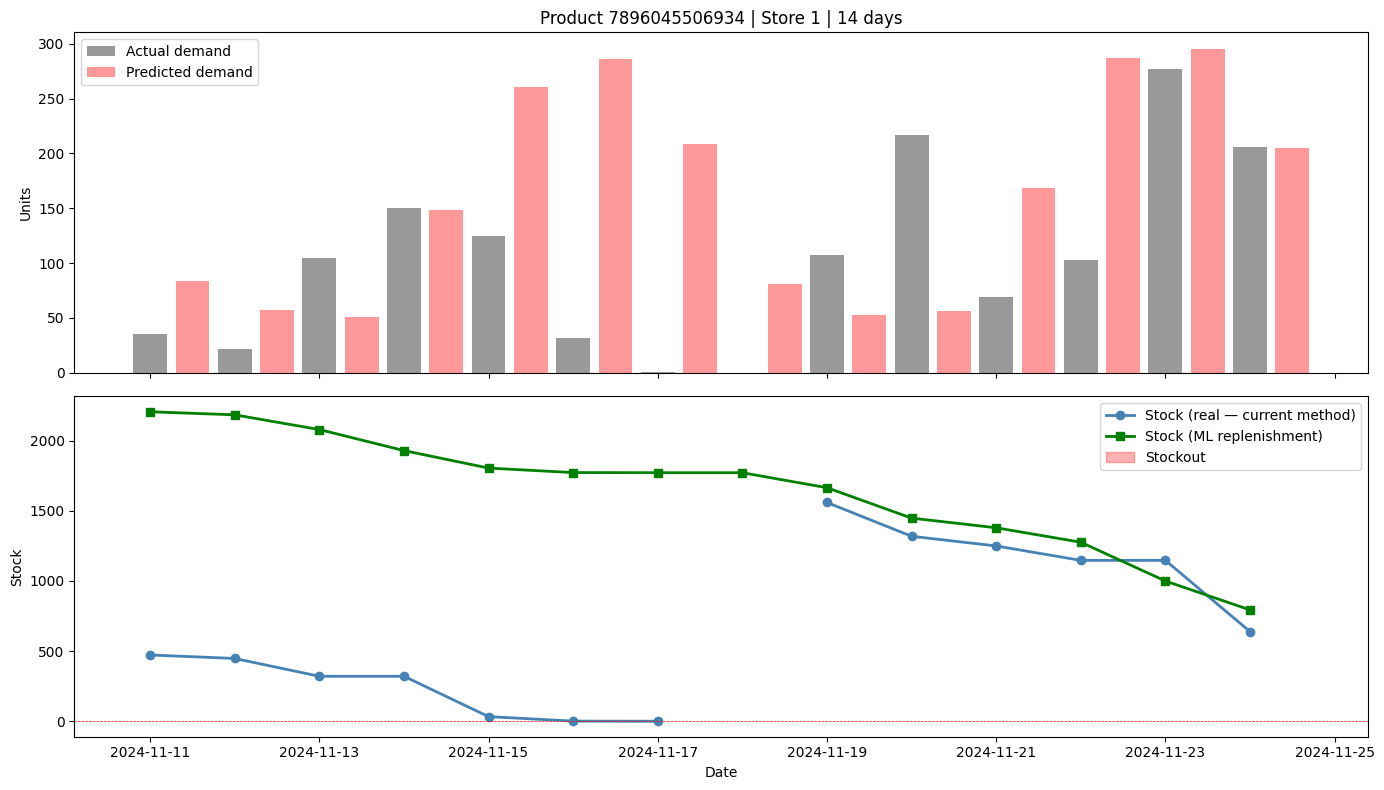

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: demand
ax1.bar(sim['date'], sim['actual'], alpha=0.4, label='Actual demand', color='black', width=0.4)
ax1.bar(sim['date'] + pd.Timedelta(hours=12), sim['prediction'], alpha=0.4, label='Predicted demand', color='red', width=0.4)
ax1.set_ylabel('Units')
ax1.set_title(f"Product {PRODUCT} | Store {STORE} | {REPLENISHMENT_DAYS} days")
ax1.legend()

# Bottom: stock comparison
if sim['stock_real'].notna().any():
    ax2.plot(sim['date'], sim['stock_real'], marker='o', label='Stock (real — current method)', color='steelblue', linewidth=2)
ax2.plot(sim['date'], sim['stock_ml'], marker='s', label='Stock (ML replenishment)', color='green', linewidth=2)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=0.5)
ax2.fill_between(sim['date'], sim['stock_ml'], 0, where=sim['stock_ml'] < 0, alpha=0.3, color='red', label='Stockout')
ax2.set_ylabel('Stock')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.show()

## 4. All stores comparison

In [9]:
all_summaries = []
for store in sorted(predictions['store_id'].unique()):
    _, s = simulate(raw, predictions, PRODUCT, store, REPLENISHMENT_DAYS)
    if s is not None:
        all_summaries.append(s)

summary_df = pd.DataFrame(all_summaries)
summary_df['stock_savings'] = summary_df['avg_stock_real'] - summary_df['avg_stock_ml']
summary_df

,product,store,days,initial_stock_real,predicted_demand,actual_demand,prediction_error,ml_replenishment_qty,final_stock_ml,stockout_days_ml,avg_stock_real,avg_stock_ml,stock_savings
0,7896045506934,1,14,507.0,2243,1449,794,2243,794,0,666,1649,-983
1,7896045506934,2,14,2972.0,1411,2160,-749,1411,-749,3,3832,564,3268
2,7896045506934,3,14,5086.0,2417,3244,-827,2417,-827,2,5675,1193,4482
3,7896045506934,4,14,4806.0,2664,2306,358,2664,358,0,3576,1538,2038
4,7896045506934,5,14,2607.0,2334,1503,831,2334,831,0,2389,1620,769
5,7896045506934,6,14,2127.0,3593,2404,1189,3593,1189,0,1493,2487,-994
6,7896045506934,7,14,3234.0,2347,1274,1073,2347,1073,0,2634,1712,922
7,7896045506934,8,14,3205.0,1592,1199,393,1592,393,0,2632,1003,1629
8,7896045506934,9,14,3872.0,1301,615,686,1301,686,0,5109,990,4119
9,7896045506934,10,14,2345.0,1755,1715,40,1755,40,0,1840,852,988


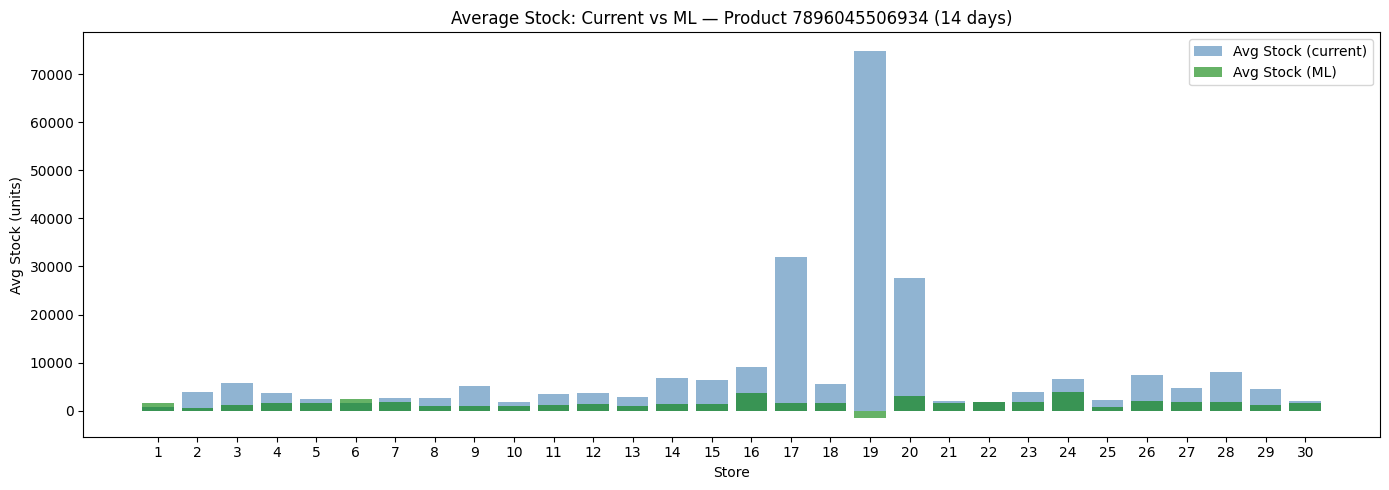

Total avg stock across stores — Current: 245692 | ML: 45658
Reduction: 200034 units (81%)


In [10]:
valid = summary_df[summary_df['avg_stock_real'].notna()]

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(valid))
ax.bar(x, valid['avg_stock_real'], alpha=0.6, label='Avg Stock (current)', color='steelblue')
ax.bar(x, valid['avg_stock_ml'], alpha=0.6, label='Avg Stock (ML)', color='green')
ax.set_xticks(x)
ax.set_xticklabels(valid['store'].astype(int))
ax.set_xlabel('Store')
ax.set_ylabel('Avg Stock (units)')
ax.set_title(f'Average Stock: Current vs ML — Product {PRODUCT} ({REPLENISHMENT_DAYS} days)')
ax.legend()
plt.tight_layout()
plt.show()

total_current = valid['avg_stock_real'].sum()
total_ml = valid['avg_stock_ml'].sum()
print(f'Total avg stock across stores — Current: {total_current:.0f} | ML: {total_ml:.0f}')
print(f'Reduction: {total_current - total_ml:.0f} units ({(total_current - total_ml) / total_current * 100:.0f}%)')